# Test the statistical method for different scenario

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

c0 = {
    "acc": "#941717",
    "cor": "#388E3C",
    "ggd": "#42A5F5",
    "wd": "#FFA000",
    "sum": "lightgrey",
}
plt.rcParams["hatch.linewidth"] = 8
from diagnosis import compute_mean_square
from cstes import U

In [2]:
N = 100000  # nb coloc

__________________________
# 1. No errors
## 1.1. Gradient wind balance

$$f\vec{k}\wedge\vec{u} +g\vec{\nabla}_z\eta = 0$$



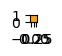

In [84]:
import numpy as np

# define normalized 2D gaussian
def gaus2d(x=0, y=0, mx=0, my=0, sx=1, sy=1):
    return (
        1.0
        / (2.0 * np.pi * sx * sy)
        * np.exp(
            -((x - mx) ** 2.0 / (2.0 * sx**2.0) + (y - my) ** 2.0 / (2.0 * sy**2.0))
        )
    )


# define normalized 2D sinus
def sin2d(X, Y, period=50e3):
    return np.sin(X / period) + np.sin(Y / period / 4)


def create_champ_geo(L=200e3, std=150e3, lat=40, dsl_amp=5e-2):
    g = 9.81
    x = np.arange(-L, L, 5e3)
    y = np.arange(-L, L, 5e3)

    X, Y = np.meshgrid(x, y)  # get 2D variables instead of 1D
    z = sin2d(X, Y)
    z = z / z.max() * dsl_amp

    ds = xr.Dataset(
        data_vars=dict(
            eta=(["y", "x"], z),
        ),
        coords=dict(
            y=("y", y),
            x=("x", x),
        ),
    )

    ds["eta"] = ds["eta"].assign_attrs({"long_name": r"DSL $\eta$", "unit": "m"})
    ds["x"] = ds["x"].assign_attrs({"unit": "m"})
    ds["y"] = ds["y"].assign_attrs({"unit": "m"})

    f = 2 * 2 * np.pi / 86164.1 * np.sin(lat * np.pi / 180)

    ds["dxeta"] = ds["eta"].differentiate("x")
    ds["dyeta"] = ds["eta"].differentiate("y")

    ds["ugx"] = g / f * ds.dyeta
    ds["ugy"] = -g / f * ds.dxeta

    def compute_u_theta(f, r, ug):
        a = -1 / 2 * f * r
        b = 1 / 2 * f * r * np.sqrt(1 + 4 * ug / f / r)
        return a - b, a + b

    ds = ds.transpose("y", "x")

    ds["corx"] = f * ds.ugy
    ds["cory"] = -f * ds.ugx
    ds["ggdx"] = g * ds.dxeta
    ds["ggdy"] = g * ds.dyeta
    # ds['corx'] = - f*ds.utheta1y
    # ds['cory'] = f*ds.utheta1x
    # ds['ggdx'] = -g*ds.dxeta
    # ds['ggdy'] = -g*ds.dyeta

    return ds


from diagnosis import compute_mean_square, put_fig_letter
from cstes import U2


def create_prod_exc_sum(df, null_mean):
    df = df.copy()
    ds = xr.Dataset()
    for direction in ["x", "y"]:
        if direction == "x":
            l = {"acc": "accx", "cor": "corx", "ggd": "ggdx", "wd": "wdx"}
        if direction == "y":
            l = {"acc": "accy", "cor": "cory", "ggd": "ggdy", "wd": "wdy"}

        if null_mean:
            for v in l:
                df[l[v]] = df[l[v]] - df[l[v]].mean()

        # sum
        ds["sum" + direction] = sum([df[l[v]] for v in l])

        # simple var + sum- one term
        for v in l:
            ds[l[v]] = df[l[v]]
            print(df[l[v]].mean())
            ds["exc" + direction + "_" + v] = ds["sum" + direction] - ds[l[v]]

        # 2 by 2 product
        import itertools

        couple = list(itertools.combinations(list(l.keys()), 2))
        for c in couple:
            ds["prod" + direction + "_" + "_".join(c)] = (
                ds[c[0] + direction] * ds[c[1] + direction]
            )
    return ds


def plot_diag(fig, ax, ds2):
    # labels = {'acc':r'$u_{\theta}^2/r$', 'cor':r'$fu_{\theta}$', 'ggd':r'$-g\partial_r\eta$', 'wd':'Wind','sum':'Residual'}
    # labels = {'acc':r'$d_t\vec{u}$', 'cor':r'$f\vec{k}\wedge u_{\theta}$', 'ggd':r'$-g\partial_r\eta$', 'wd':'Wind','sum':'Residual'}
    labels = {
        "acc": "Lagrangina acceleration",
        "cor": "Coriolis accelration",
        "ggd": "Pressure gradient term",
        "wd": "Wind",
        "sum": "Residual",
    }
    plt.rcParams["axes.edgecolor"] = "k"
    df = ds.to_dataframe()
    var = ["acc", "cor", "ggd", "wd"]
    i = 0
    for v in var:
        # total MS
        ax.bar(i, ds2[v.upper()], color=c0[v], alpha=0.5)

        # B and E
        if ds2["B_" + v] > 0:
            ax.bar(i, ds2["B_" + v], color=c0[v], width=0.7, label=labels[v])
            if ds2["E_" + v] < 0:
                ax.bar(i, ds2["E_" + v], color="lightgrey", width=0.7)
            else:
                ax.bar(
                    i, ds2["E_" + v], bottom=ds2["B_" + v], color="lightgrey", width=0.7
                )
        else:
            ax.bar(i, ds2["B_" + v], color=c0[v], width=0.7)
            if ds2["E_" + v] > 0:
                ax.bar(i, ds2["E_" + v], color="lightgrey", width=0.7)
            else:
                ax.bar(
                    i, ds2["E_" + v], bottom=ds2["B_" + v], color="lightgrey", width=0.7
                )

        # X
        X_var = [x for x in ds2 if (("X_" in x) & (v in x) & ("ser_" not in x))]
        pos_X = [x for x in X_var if ds2[x] > 0]
        neg_X = [x for x in X_var if x not in pos_X]

        sum_posX = 0
        for X in pos_X:
            xc = X.replace("X_", "").split("_")
            plt.rcParams["hatch.color"] = c0[xc[0]]
            ax.bar(
                i, ds2[X] / 2, bottom=sum_posX, color=c0[xc[1]], hatch="/", width=0.5
            )
            sum_posX += ds2[X] / 2

        sum_negX = 0
        for X in neg_X:
            xc = X.replace("X_", "").split("_")
            plt.rcParams["hatch.color"] = c0[xc[0]]
            ax.bar(
                i, ds2[X] / 2, bottom=sum_negX, color=c0[xc[1]], hatch="/", width=0.5
            )
            sum_negX += ds2[X] / 2
        i += 1
    ax.bar(i, ds2["S"], color="lightgrey")
    ax.grid()
    # ax.legend()
    ax.set_ylabel(r"[$\gamma^2$]")


fig, ax = plt.subplots(figsize=(0.1, 0.1))
ax.bar(0, 1, color=c0["acc"], label="Lagrangian acceleration")
ax.bar(0, 1, color=c0["cor"], label="Coriolis acceleration")
ax.bar(0, 1, color=c0["ggd"], label="Pressure gradient term")
ax.bar(0, 1, color=c0["wd"], label="Wind term")
# ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()

_____________________
# Anticyclonic eddy

0.0
1.3597563672691733e-22
-7.534955665759113e-23
0.0
0.0
7.101912236692497e-23
-1.212521601386524e-23
0.0
0.0
6.301447460500179e-07
-6.30144746050018e-07
0.0
0.0
-1.1360282788098136e-06
1.1360282788098136e-06
0.0


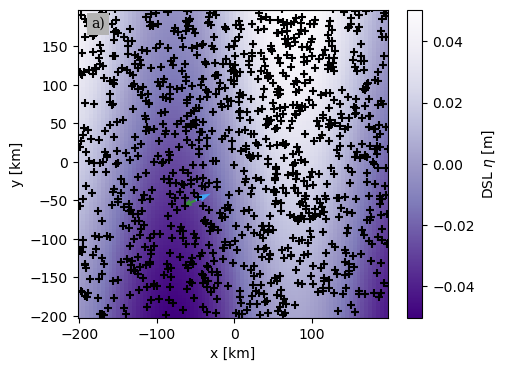

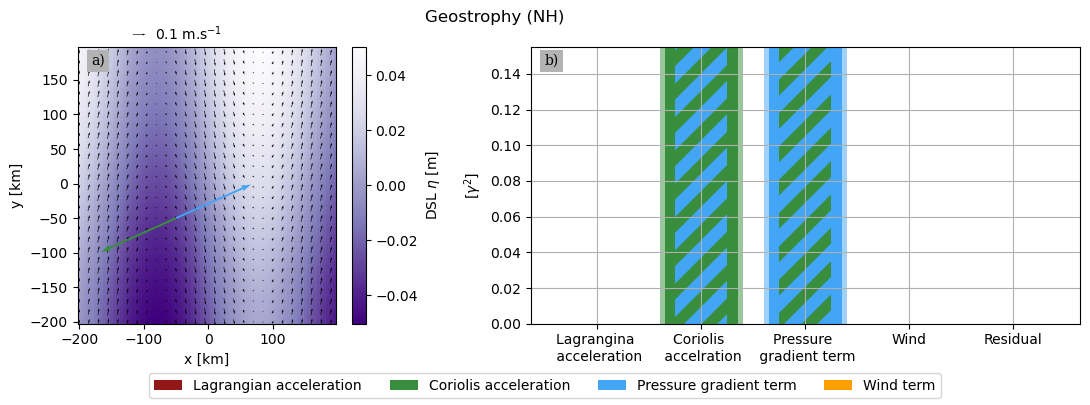

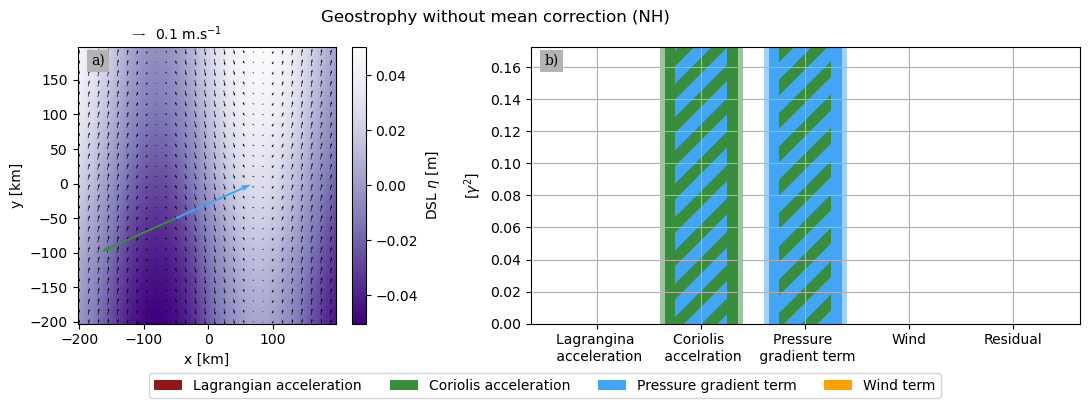

In [143]:
# Create eddy
L = 200e3
ds = create_champ_geo()

# Coloc
xa = np.random.uniform(-1, 1, 1000) * L
ya = np.random.uniform(-1, 1, 1000) * L
dsa = ds.interp(x=("row_number", xa), y=("row_number", ya))

# check for sampling
# dsa=dsa.where(dsa.y>0, drop=True)

ds["x"] = (ds.x / 1000).assign_attrs({"units": "km"})
ds["y"] = (ds.y / 1000).assign_attrs({"units": "km"})
dsa["x"] = (dsa.x / 1000).assign_attrs({"units": "km"})
dsa["y"] = (dsa.y / 1000).assign_attrs({"units": "km"})

dsa["wdx"] = dsa["corx"] / dsa["corx"] - 1
dsa["wdy"] = dsa["corx"] / dsa["corx"] - 1
dsa["accx"] = dsa["corx"] / dsa["corx"] - 1
dsa["accy"] = dsa["corx"] / dsa["corx"] - 1

dfa = dsa.to_dataframe()
dsa_ = create_prod_exc_sum(dfa, null_mean=True)
dsanc_ = create_prod_exc_sum(dfa, null_mean=False)

# Reconstruction dataset
dsm = compute_mean_square(dsa_, dirname=("x", "y")) / U2
dsmnc = compute_mean_square(dsanc_, dirname=("x", "y")) / U2


# FIGURES

fig, ax = plt.subplots(1, 1, frameon=False, figsize=(5, 4))
ds.eta.plot(ax=ax, cmap="Purples_r")
put_fig_letter(fig, ax, "a")
kwargs = {"pivot": "tail", "scale": 6e-5, "add_guide": False}
a = ds.isel(x=30, y=30).plot.quiver(
    x="x", y="y", u="corx", v="cory", ax=ax, color=c0["cor"], **kwargs
)
a = ds.isel(x=30, y=30).plot.quiver(
    x="x", y="y", u="ggdx", v="ggdy", ax=ax, color=c0["ggd"], **kwargs
)
ax.set_title("")

dsa.plot.scatter(x="x", y="y", marker="+", color="k")

# fig, axs = plt.subplots(1,1, frameon=False, figsize=(5, 4))
# ds.eta.plot(ax=axs, cmap='Blues_r')
# a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(x='x', y='y', u='utheta1x', v='utheta1y', ax=axs)
# kwargs={'pivot':'tail', 'scale':3e-5}

# a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='corx', v='cory', ax=axs, color=c0['cor'], **kwargs)
# a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='ggdx', v='ggdy', ax=axs, color=c0['ggd'], **kwargs)
# a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='accx', v='accy', ax=axs, color=c0['acc'], **kwargs)
# fig.tight_layout()

####################################

from matplotlib.gridspec import GridSpec

fig = plt.figure(frameon=False, figsize=(10, 4))
gs = GridSpec(1, 5, figure=fig)

# Visualize row series
i = 0
ax = fig.add_subplot(gs[0, :2])
ds.eta.plot(ax=ax, cmap="Purples_r")
put_fig_letter(fig, ax, "a")
a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(
    x="x", y="y", u="ugx", v="ugy", ax=ax, color="k", add_guide=False
)
ax.quiverkey(
    a, 0.15, 0.92, 0.1, r"0.1 m.s$^{-1}$", coordinates="figure", labelpos="E", color="k"
)

kwargs = {"pivot": "tail", "scale": 1e-5, "add_guide": False}
a = ds.isel(x=30, y=30).plot.quiver(
    x="x", y="y", u="corx", v="cory", ax=ax, color=c0["cor"], **kwargs
)
a = ds.isel(x=30, y=30).plot.quiver(
    x="x", y="y", u="ggdx", v="ggdy", ax=ax, color=c0["ggd"], **kwargs
)
ax.set_title("")

# Reconstruction data
ax = fig.add_subplot(gs[0, 2:])
plot_diag(fig, ax, dsm)
# ax.set_xticks(ticks = np.arange(5),labels = [r'$u_{\theta}^2/r$', r'$fu_{\theta}$', r'$-g\partial_r\eta$', 'Wind','Residual'] )
ax.set_xticks(
    ticks=np.arange(5),
    labels=[
        "Lagrangina \n acceleration",
        "Coriolis \n accelration",
        "Pressure \n gradient term",
        "Wind",
        "Residual",
    ],
)
fig.suptitle("Geostrophy (NH)")
fig.legend(handles, labels, ncol=4, loc="lower center")
put_fig_letter(fig, ax, "b")

fig.tight_layout(rect=[0, 0.05, 1.1, 1])


## No mean correction
from matplotlib.gridspec import GridSpec

fig = plt.figure(frameon=False, figsize=(10, 4))
gs = GridSpec(1, 5, figure=fig)

# Visualize row series
i = 0
ax = fig.add_subplot(gs[0, :2])
ds.eta.plot(ax=ax, cmap="Purples_r")
put_fig_letter(fig, ax, "a")
a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(
    x="x", y="y", u="ugx", v="ugy", ax=ax, color="k", add_guide=False
)
ax.quiverkey(
    a, 0.15, 0.92, 0.1, r"0.1 m.s$^{-1}$", coordinates="figure", labelpos="E", color="k"
)

kwargs = {"pivot": "tail", "scale": 1e-5, "add_guide": False}
a = ds.isel(x=30, y=30).plot.quiver(
    x="x", y="y", u="corx", v="cory", ax=ax, color=c0["cor"], **kwargs
)
a = ds.isel(x=30, y=30).plot.quiver(
    x="x", y="y", u="ggdx", v="ggdy", ax=ax, color=c0["ggd"], **kwargs
)
ax.set_title("")

# Reconstruction data
ax = fig.add_subplot(gs[0, 2:])
plot_diag(fig, ax, dsmnc)
# ax.set_xticks(ticks = np.arange(5),labels = [r'$u_{\theta}^2/r$', r'$fu_{\theta}$', r'$-g\partial_r\eta$', 'Wind','Residual'] )
ax.set_xticks(
    ticks=np.arange(5),
    labels=[
        "Lagrangina \n acceleration",
        "Coriolis \n accelration",
        "Pressure \n gradient term",
        "Wind",
        "Residual",
    ],
)
fig.suptitle("Geostrophy without mean correction (NH)")
fig.legend(handles, labels, ncol=4, loc="lower center")
put_fig_letter(fig, ax, "b")

fig.tight_layout(rect=[0, 0.05, 1.1, 1])

In [142]:
(
    (-dsanc_.corx.mean() * dsanc_.ggdx.mean())
    + (-dsanc_.cory.mean() * dsanc_.ggdy.mean())
) / U2 + 0.16

<xarray.DataArray ()> Size: 8B
array(0.1823982)

0.0
9.478601483260422e-07
-9.478601483260424e-07
0.0
0.0
-1.137279276010576e-06
1.1372792760105762e-06
0.0


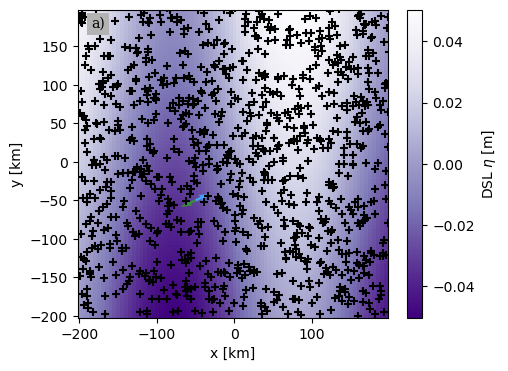

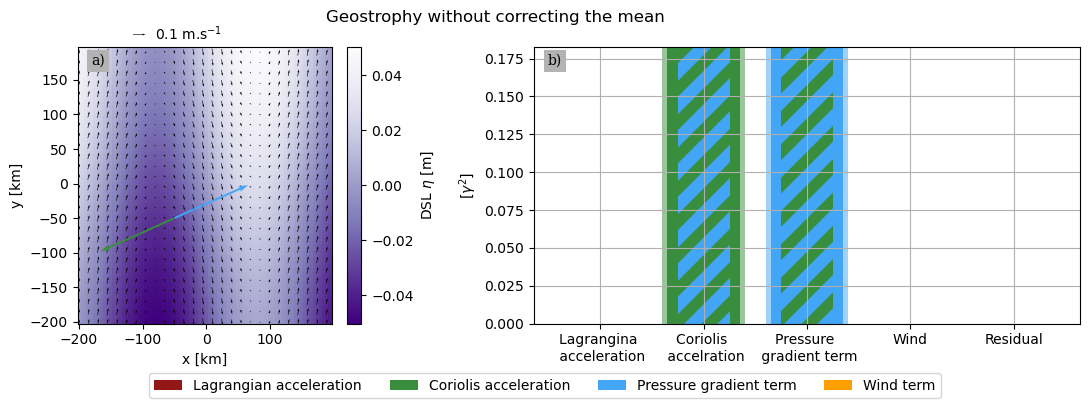

In [125]:
# Create eddy
L = 200e3
ds = create_champ_geo()

# Coloc
xa = np.random.uniform(-1, 1, 1000) * L
ya = np.random.uniform(-1, 1, 1000) * L
dsa = ds.interp(x=("row_number", xa), y=("row_number", ya))

# check for sampling
# dsa=dsa.where(dsa.y>0, drop=True)

ds["x"] = (ds.x / 1000).assign_attrs({"units": "km"})
ds["y"] = (ds.y / 1000).assign_attrs({"units": "km"})
dsa["x"] = (dsa.x / 1000).assign_attrs({"units": "km"})
dsa["y"] = (dsa.y / 1000).assign_attrs({"units": "km"})

dsa["wdx"] = dsa["corx"] / dsa["corx"] - 1
dsa["wdy"] = dsa["corx"] / dsa["corx"] - 1
dsa["accx"] = dsa["corx"] / dsa["corx"] - 1
dsa["accy"] = dsa["corx"] / dsa["corx"] - 1

dfa = dsa.to_dataframe()
# dsa_ = create_prod_exc_sum(dfa, null_mean = True)
dsa_ = create_prod_exc_sum(dfa, null_mean=False)

# Reconstruction dataset
dsm = compute_mean_square(dsa_, dirname=("x", "y")) / U2

# FIGURES

fig, ax = plt.subplots(1, 1, frameon=False, figsize=(5, 4))
ds.eta.plot(ax=ax, cmap="Purples_r")
put_fig_letter(fig, ax, "a")
kwargs = {"pivot": "tail", "scale": 6e-5, "add_guide": False}
a = ds.isel(x=30, y=30).plot.quiver(
    x="x", y="y", u="corx", v="cory", ax=ax, color=c0["cor"], **kwargs
)
a = ds.isel(x=30, y=30).plot.quiver(
    x="x", y="y", u="ggdx", v="ggdy", ax=ax, color=c0["ggd"], **kwargs
)
ax.set_title("")

dsa.plot.scatter(x="x", y="y", marker="+", color="k")

# fig, axs = plt.subplots(1,1, frameon=False, figsize=(5, 4))
# ds.eta.plot(ax=axs, cmap='Blues_r')
# a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(x='x', y='y', u='utheta1x', v='utheta1y', ax=axs)
# kwargs={'pivot':'tail', 'scale':3e-5}

# a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='corx', v='cory', ax=axs, color=c0['cor'], **kwargs)
# a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='ggdx', v='ggdy', ax=axs, color=c0['ggd'], **kwargs)
# a = ds.isel(x=30, y=30).plot.quiver(x='x', y='y', u='accx', v='accy', ax=axs, color=c0['acc'], **kwargs)
# fig.tight_layout()

####################################

from matplotlib.gridspec import GridSpec

fig = plt.figure(frameon=False, figsize=(10, 4))
gs = GridSpec(1, 5, figure=fig)

# Visualize row series
i = 0
ax = fig.add_subplot(gs[0, :2])
ds.eta.plot(ax=ax, cmap="Purples_r")
put_fig_letter(fig, ax, "a")
a = ds.isel(x=slice(0, -1, 3), y=slice(0, -1, 3)).plot.quiver(
    x="x", y="y", u="ugx", v="ugy", ax=ax, color="k", add_guide=False
)
ax.quiverkey(
    a, 0.15, 0.92, 0.1, r"0.1 m.s$^{-1}$", coordinates="figure", labelpos="E", color="k"
)
kwargs = {"pivot": "tail", "scale": 1e-5, "add_guide": False}
a = ds.isel(x=30, y=30).plot.quiver(
    x="x", y="y", u="corx", v="cory", ax=ax, color=c0["cor"], **kwargs
)
a = ds.isel(x=30, y=30).plot.quiver(
    x="x", y="y", u="ggdx", v="ggdy", ax=ax, color=c0["ggd"], **kwargs
)
ax.set_title("")

# Reconstruction data
ax = fig.add_subplot(gs[0, 2:])
plot_diag(fig, ax, dsm)
# ax.set_xticks(ticks = np.arange(5),labels = [r'$u_{\theta}^2/r$', r'$fu_{\theta}$', r'$-g\partial_r\eta$', 'Wind','Residual'] )
ax.set_xticks(
    ticks=np.arange(5),
    labels=[
        "Lagrangina \n acceleration",
        "Coriolis \n accelration",
        "Pressure \n gradient term",
        "Wind",
        "Residual",
    ],
)
fig.suptitle("Geostrophy without correcting the mean")
fig.legend(handles, labels, ncol=4, loc="lower center")
put_fig_letter(fig, ax, "b")

fig.tight_layout(rect=[0, 0.05, 1.1, 1])

In [128]:
dsa_.mean()

<xarray.Dataset> Size: 240B
Dimensions:        ()
Data variables: (12/30)
    sumx           float64 8B -6.754e-23
    accx           float64 8B 0.0
    excx_acc       float64 8B -6.754e-23
    corx           float64 8B 9.479e-07
    excx_cor       float64 8B -9.479e-07
    ggdx           float64 8B -9.479e-07
    ...             ...
    prody_acc_cor  float64 8B 0.0
    prody_acc_ggd  float64 8B 0.0
    prody_acc_wd   float64 8B 0.0
    prody_cor_ggd  float64 8B -1.326e-12
    prody_cor_wd   float64 8B 0.0
    prody_ggd_wd   float64 8B 0.0

In [129]:
((-2 * dsa_.corx * dsa_.ggdx) + (-2 * dsa_.cory * dsa_.ggdy)).mean() / U2

<xarray.DataArray ()> Size: 8B
array(0.3652625)

In [120]:
dsa_.mean()

<xarray.Dataset> Size: 240B
Dimensions:        ()
Data variables: (12/30)
    sumx           float64 8B -8.66e-23
    accx           float64 8B 0.0
    excx_acc       float64 8B -8.66e-23
    corx           float64 8B 9.894e-07
    excx_cor       float64 8B -9.894e-07
    ggdx           float64 8B -9.894e-07
    ...             ...
    prody_acc_cor  float64 8B 0.0
    prody_acc_ggd  float64 8B 0.0
    prody_acc_wd   float64 8B 0.0
    prody_cor_ggd  float64 8B -1.332e-12
    prody_cor_wd   float64 8B 0.0
    prody_ggd_wd   float64 8B 0.0